## Sensitivity Matrix Computation

Recall that `Pyomo.DoE`  utilizes the sensitivity matrix defined as the derivative of the estimates of the measured outputs $\hat{y}$ with respect to the parameter to be estimated $\hat{\theta}$:
$$
Q = \nabla_{\hat{\theta}} \hat{y}
$$
to compute the FIM as:
$$
M = Q^T \Sigma^{-1}Q 
$$
where $\Sigma$ is the measurement covariance matrix

Pyomo.DoE offers two different approaches to computing the sensitivity matrix:
1. Finite difference method: With Central finite difference method that utilizes parameter perturbations for estimating the sensitivity matrix as: $$Q \approx \frac{\hat{y}(\hat{\theta} + \Delta \hat{\theta})- \hat{y}(\hat{\theta} - \Delta \hat{\theta})}{2 \Delta \hat{\theta}}$$ where $\Delta \hat{\theta}$ is the step size. This method requires $2n_p+1$ copies of the base model to solve. Therefore, its computational complexity increases with the number of parameters
2. Automatic differentiation method: Pyomo.DoE uses automatic differentiation in PyNumero to compute sensitivities directly from the model equations, avoiding repeated parameter perturbation solves: $$\nabla_{\hat{\theta}}F = \begin{bmatrix}\nabla_{\hat{y}}F\\\nabla_{\hat{x}}F\end{bmatrix}\begin{bmatrix}\nabla_{\hat{\theta}}\hat{y}\\\nabla_{\hat{\theta}}\hat{x}\end{bmatrix}$$ where $F(\hat{x},\hat{y}, \hat{\theta}, u) = 0$ is the model of the system. This method does not require multiple copies of the original model, and therefore, is expected to reduce the total computation time.



Now that we have introduced the two sensitivity calculation methods, we compare their computational cost. Both approaches produce the sensitivity matrix needed to assemble the FIM, but they differ in how many model evaluations they require.

The finite-difference approach estimates sensitivities by repeatedly perturbing parameters and resolving the model. This can become expensive as the number of parameters grows. In contrast, the automatic differentiation approach computes sensitivities directly from the model equations using PyNumero, avoiding repeated finite-difference solves.

Next, we time both methods on the TC Lab example and compare the resulting FIM calculations.

In [19]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)

We will load the sine test data to serve as an initial point. Recall our create model function will use supplied data to initialize the Pyomo model. Carefully initialization is often required for optimization of large-scale dynamic systems.

In [20]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)


We will create the data object for the design of experiment problems that follow

In [21]:
# Here, we will induce a step size of 15 seconds, as to not give too many 
# degrees of freedom for experimental design.
skip =15

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

## Calculate FIM at initial point (Values from $L_2$ regularization)

We will start by re-computing the prior FIM from $L_2$ regularization

In [22]:
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

from pyomo.environ import SolverFactory

# Copied from previous notebook
theta_values = {
    'Ua': 0.041705,
    'Ub': 0.012009,
    'inv_CpH': 0.167457,
    'inv_CpS': 4.545432,
}

In [23]:
#Defining the prior

import numpy as np

cov = np.array([
    [1.857017e-10, -2.576198e-10, 1.402148e-09, -2.242347e-12],
    [-2.576198e-10, 1.624383e-07, 9.10987e-08, -6.32555e-05],
    [1.402148e-09, 9.10987e-08, 1.031454e-07, -3.890789e-05],
    [-2.242347e-12, -6.325555e-05, -3.890789e-05, 2.499914e-02],
])

FIM = np.linalg.inv(cov)

# Make sure resultant FIM is symmetric within numerical tolerance

FIM = 0.5*(FIM + FIM.T)



In [24]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)

solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-5
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"
solver.options["acceptable_tol"] = 1e-3


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=False, 
                                 prior_FIM=FIM,
                                 tee=True,
                                 solver = solver,)

# Get the FIM and the jacobian at the initial solve
try:
    init_fim = TC_Lab_DoE.compute_FIM()
    init_jac = TC_Lab_DoE.seq_jac 
except:
    init_fim = None
    init_jac = None

Ipopt 3.14.19: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based
acceptable_tol=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:      720
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      242
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      120
                     variables with only upper bo

## Optimize next experiment (A-optimality) using central finite difference method

We are now ready to solve the next experiment design problem. Here, we create a new `DesignOfExperiments` object and pass in the `prior_FIM`, which represents the information already collected from the previous experiment. By optimizing with this prior information included, Pyomo.DoE identifies the next best experiment to run according to the selected design criterion. In this section, we use A-optimality by setting `objective_option="trace"`.

In [25]:
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=False,
                                 objective_option="trace",  # Now we specify a type of objective, D-opt = "determinant"
                                 prior_FIM=FIM,  # We use the prior information from the existing experiment!,,,,,,,,,,,,,,,,,,,,,,,
                                 tee=False,
                                 solver = solver,
                                jac_initial=init_jac,
                                fim_initial=init_fim,)
TC_Lab_DoE_A.use_grey_box = True
TC_Lab_DoE_A.run_doe()

## Run A-optimality experiment using automatic differentiation

We now use the automatic differentiation method to compute sensitivities by setitng `gradient_method = 'pynumero`

In [26]:

#
# Create experiment object for design of experiments
doe_experiment = TC_Lab_experiment(data=tc_data, theta_initial=theta_values, number_of_states=number_tclab_states)

# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A_AD = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=False,
                                 gradient_method = "pynumero",
                                 objective_option="trace",  # Now we specify a type of objective, D-opt = "determinant"
                                 prior_FIM=FIM,  # We use the prior information from the existing experiment!,,,,,,,,,,,,,,,,,,,,,,,
                                 tee=False,
                                 solver = solver,
                                jac_initial=init_jac,
                                fim_initial=init_fim,)

TC_Lab_DoE_A_AD.run_doe()

## Comparison of the Central Finite Difference and Automatic Differentiation Methods' Computational Time

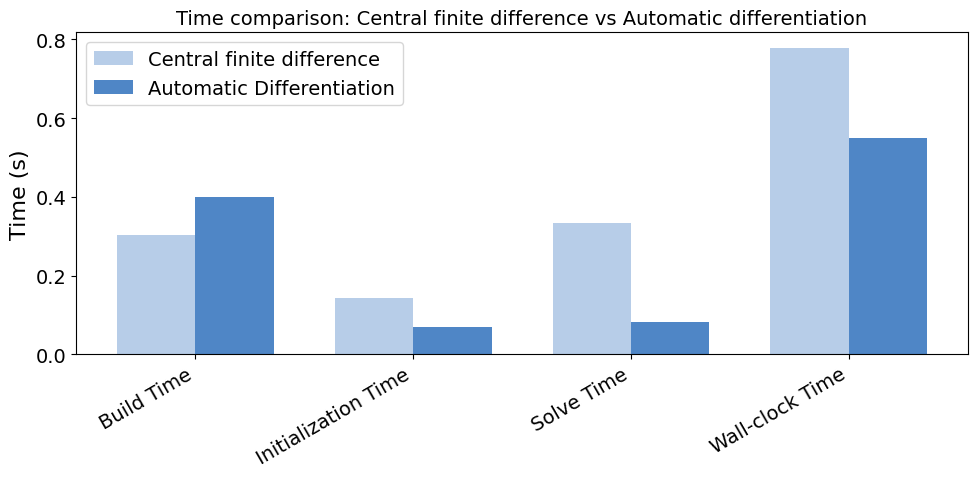

In [27]:
import matplotlib.pyplot as plt
import numpy as np

central_time_metrics = {
    "Build Time": TC_Lab_DoE_A.results.get("Build Time"),
    "Initialization Time": TC_Lab_DoE_A.results.get("Initialization Time"),
    "Solve Time": TC_Lab_DoE_A.results.get("Solve Time"),
    "Wall-clock Time": TC_Lab_DoE_A.results.get("Wall-clock Time"),
}

AD_time_metrics = {
    "Build Time": TC_Lab_DoE_A_AD.results.get("Build Time"),
    "Initialization Time": TC_Lab_DoE_A_AD.results.get("Initialization Time"),
    "Solve Time": TC_Lab_DoE_A_AD.results.get("Solve Time"),
    "Wall-clock Time": TC_Lab_DoE_A_AD.results.get("Wall-clock Time"),
}

labels = []
central_vals = []
AD_vals = []

for key in central_time_metrics:
    c = central_time_metrics.get(key)
    s = AD_time_metrics.get(key)
    if c is None or s is None:
        continue
    try:
        c = float(c)
        s = float(s)
    except (TypeError, ValueError):
        continue
    labels.append(key)
    central_vals.append(c)
    AD_vals.append(s)

x = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, central_vals, width, label="Central finite difference", color="#b7cde8")
plt.bar(x + width/2, AD_vals, width, label="Automatic Differentiation", color="#4f86c6")

plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("Time (s)")
plt.title("Time comparison: Central finite difference vs Automatic differentiation")
plt.legend()
plt.tight_layout()
plt.show()


The timing comparison separates the workflow into model build time, initialization time, solve time, and total wall-clock time. In this run, the automatic differentiation formulation takes longer to build, but it solves much faster than the central finite difference formulation.

This tradeoff is expected. Automatic differentiation requires additional setup to construct derivative information directly from the model equations, which increases the build time. However, once that derivative information is available, the optimizer can use it efficiently during the solve.

In contrast, the central finite difference formulation estimates sensitivities by applying parameter perturbations and resolving perturbed model instances. These additional perturbation-based calculations make the solve phase more expensive. For this example, the longer finite-difference solve time dominates the total wall-clock time, so the automatic differentiation workflow is faster overall.